In [22]:
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
# from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt

import math
import plotly.express as px


In [23]:
df = pd.read_csv("../data/papers.csv")
total_papers = len(df)
df.columns


Index(['Title', 'Database', 'Year', 'Month', 'Journal or Conference',
       'Paper Type', 'Data Source', 'Data Country', 'Data Domain',
       'Data Language', 'Data Availability', 'Link to Data', 'Data Details',
       'Size', 'Number of Prompts If Applicable', 'Medical Application',
       'Task Type', 'Topic', 'Note', 'Bias Evaluation Metric',
       'Bias Definition', 'Conclusions', 'Race or Ethnic Bias', 'Gender Bias',
       'Language Bias', 'Age Bias', 'Other Bias', 'LGBTQ+ Bias',
       'Disability Bias', 'Geography or Cultural Bias', 'Evaluated LLMs',
       'Reference Standard', 'Patient Inclusion', 'Has Debiasing',
       'Debias Focus', 'Debiasing Method', 'Debias Details'],
      dtype='str')

In [24]:
llms_lst = df["Evaluated LLMs"].dropna().tolist()

In [25]:
# Model family membership is defined in the next cell and applied when plotting.


In [26]:
gpt = [
    "ChatGPT", "ChatGPT-3", "GPT-3", "ChatGPT3.5", "ChatGPT 3.5", "ChatGPT-3.5", "ChatGPT-3.5-turbo",
    "ChatGPT-3.5-Turbo", "ChatGPT GPT-3.5-Turbo-0301", "GPT-3.5", "GPT-3.5-turbo",
    "GPT-3.5 Turbo", "GPT-3.5-Turbo", "GPT3.5-turbo", "ChatGPT (GPT-3.5 version)",
    "ChatGPT (3.5 versions May 12", "ChatGPT-4", "ChatGPT-4.0", "ChatGPT 4.0", "ChatGPT4",
    "ChatGPT-4.5", "ChatGPT-4o", "ChatGPT 4o", "ChatGPT-4o", "ChatGPT\u20114o", "ChatGPT-4o-mini",
    "GPT-4", "GPT-4", "GPT-4 Turbo",
    "GPT-4o", "GPT-4o-mini", "GPT-4-o", "OpenAI’s GPT-4", "ChatGPT GPT-4", "COT-ChatGPT-4",
    "Agent-ChatGPT-4", "GPT-3.5-Turbo and GPT-4", "ChatGPT-2", "GPT-2", "GPT-2",
    "Stanford Medicine Secure GPT",
]

gemini = [
    "Gemini", "Gemini 1.5 Flash", "Gemini-1.5-Flash", "Gemini-1.0-pro", "Gemini 1.5 Pro",
    "Gemini-3.5-Flash", "Gemini-3.5-Flash)", "Gemini-1.0", "Gemini-1.5"
]


llama = [
    "LLaMA", "LLaMA-2", "Llama-2 (13b)", "Llama-2 (7b)", "Llama 2-13B", "Llama-3.1-8B", 
    "Llama-3.1-70B", "Llama3-70b", "LLama3-70B", "Llama3.1-403B", "Llama-3-70b", 
    "Llama-3.1-Instruct-8B", "Llama-3.1-Instruct-70B", "Llama-3.2-3B Instruct", 
    "Llama3-Med42-8B", "Llama3-8B", "and Llama3-8B", "LLaMA-3.2-3B-Instruct", 
    "Llama-3.1-8B-Instruct", "LLaMA-3.2", "Llama3-I-70B", "Llama3-I-8B", 
    "COT-LLaMA-3 60 56 52 66\nSFT-LoRA", "Llama-3.1-8B", "Llama-3.1-70B", "Llama3-70b", 
    "LLama3-70B", "Llama3.1-403B", "Llama-3-70b", "Llama-3.1-Instruct-8B", 
    "Llama-3.1-Instruct-70B", "Llama-3.2-3B Instruct", "Llama3-Med42-8B", "Llama3-8B", 
    "and Llama3-8B", "LLaMA-3.2-3B-Instruct", "Llama-3.1-8B-Instruct", "LLaMA-3.2", 
    "Llama3-I-70B", "Llama3-I-8B", "COT-LLaMA-3 60 56 52 66\nSFT-LoRA",
]


claude = [
    "COT-Claude-3", "Claude 3 Haiku", "Haiku", "Claude-3-5-sonnet-20240620",
    "Claude 3.5 Sonnet", "Claude-3.5-Sonnet", "Claude-2.1", "Claude-3.0"
]

qwen = [
    "Qwen-turbo", "Qwen1.5-72b", "Qwen1.5-70B-Chat", "Qwen1.5-70B-Chat", "Qwen1.5-7B-Chat",
    "Qwen1.5-7B-SFT", "Qwen-14B", "Qwen2-7B", "Qwen2-72B",
]

mistral = [
    "Mistral (7b)", "Mistral-7B-v0.1", "Mistral-7B", "Mistral-I-7B", 
    "mistralai/Mistral-Small-Instruct-2409", "Mistral-Large-Instruct-2407", "Mistral-del",
]

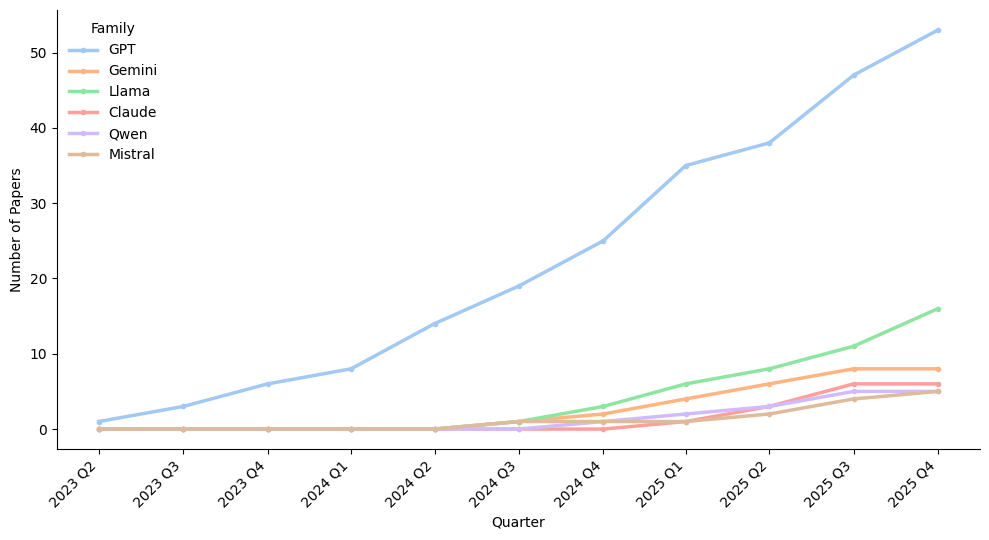

In [27]:
model_groups = {
    "GPT": gpt, "Gemini": gemini, "Llama": llama,
    "Claude": claude, "Qwen": qwen, "Mistral": mistral,
}

model_to_family = {}
for family, names in model_groups.items():
    for name in names:
        model_to_family[name] = family

family_order = ["GPT", "Gemini", "Llama", "Claude", "Qwen", "Mistral"]

plot_df = df.copy()
plot_df["_date"] = pd.to_datetime(
    plot_df["Month"].astype(str) + " " + plot_df["Year"].astype(str),
    format="%B %Y",
    errors="coerce",
)
plot_df = plot_df[plot_df["_date"].notna() & plot_df["Evaluated LLMs"].notna()].copy()
plot_df["quarter"] = plot_df["_date"].dt.to_period("Q")

records = []
for _, row in plot_df.iterrows():
    q = row["quarter"]
    families = set()
    for raw in str(row["Evaluated LLMs"]).split(","):
        name = raw.strip()
        fam = model_to_family.get(name)
        if fam is not None:
            families.add(fam)
    for fam in families:
        records.append({"quarter": q, "family": fam})

quarterly = (
    pd.DataFrame(records)
    .groupby(["quarter", "family"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=family_order, fill_value=0)
    .sort_index()
)
cumulative = quarterly.cumsum()
quarter_end = cumulative.index.to_timestamp(how="end")

import seaborn as sns

_palette = sns.color_palette("pastel", n_colors=len(family_order))
_colors = dict(zip(family_order, _palette))

fig, ax = plt.subplots(figsize=(10, 5.5))
for fam in family_order:
    if fam in cumulative.columns:
        ax.plot(
            quarter_end,
            cumulative[fam],
            marker="o",
            markersize=3,
            linewidth=2.5,
            label=fam,
            color=_colors[fam],
        )

ax.set_xlabel("Quarter")
ax.set_ylabel("Number of Papers")
ax.legend(title="Family", frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks(quarter_end)
ax.set_xticklabels([f"{p.year} Q{p.quarter}" for p in cumulative.index], rotation=45, ha="right")
fig.tight_layout()
fig.savefig("model_families_cumulative_quarterly.png", dpi=200, bbox_inches="tight")
plt.show()

/var/folders/04/2hwl1j9x5yl1hdpnd9k3jlqw0000gn/T/ipykernel_67528/273336741.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=label_rotation, ha="right")


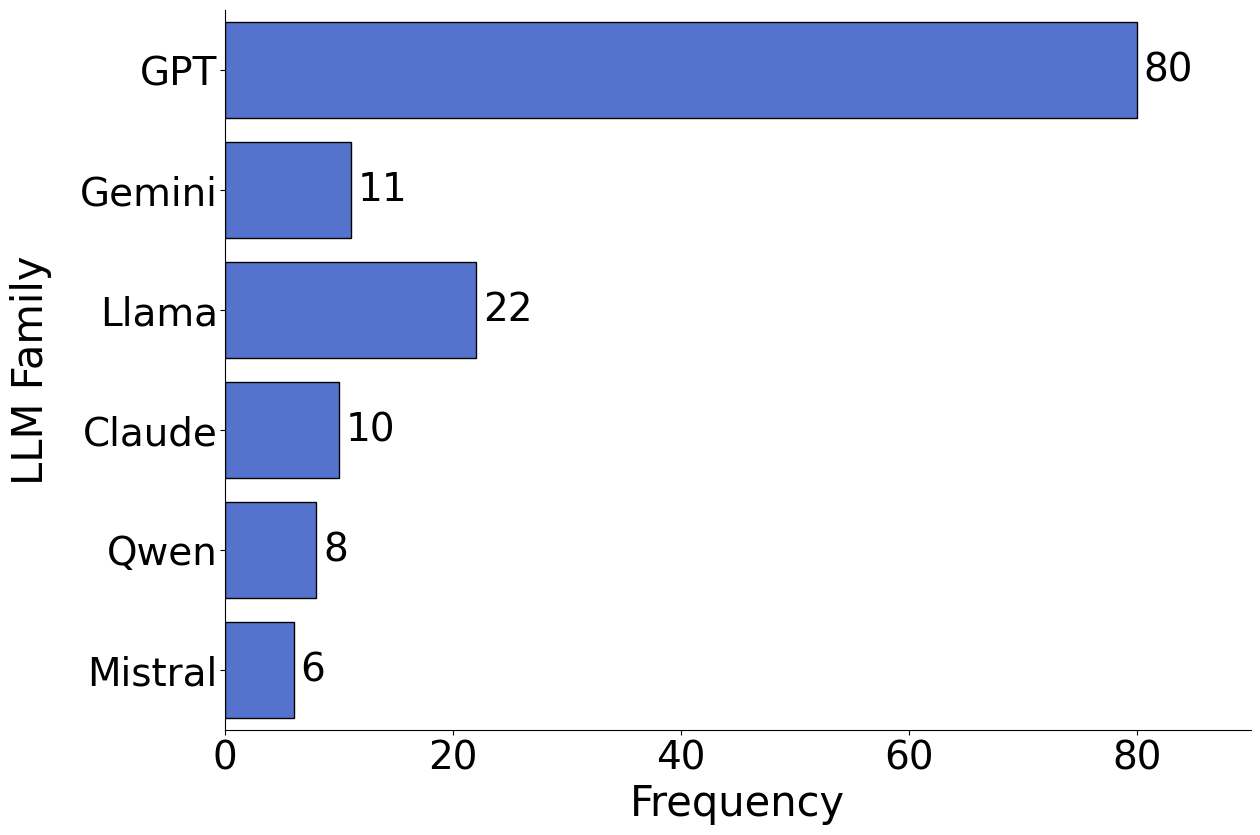

In [ ]:
import seaborn as sns

label_rotation = 0  # degrees; tilts y-axis category labels (use 0 for horizontal text)
x_tick_labelsize = 28  # tick label font size on both axes

# Axis titles ("Frequency", "LLM Family"): False hides both; or comment out the block below.
SHOW_AXIS_TITLES = True
axis_title_fontsize = 30

# Horizontal gap between bar end and count label (x-axis data units); increase for more space.
count_label_pad = 0.6
count_label_fontsize = 28

# Space (points) between the rotated y-axis title ("LLM Family") and the category labels.
y_axis_title_labelpad = 20
SAVE_SVG = True
svg_path = "llms_evaluated_frequency.svg"

family_freq = Counter()
for entry in llms_lst:
    for raw in entry.split(","):
        name = raw.strip()
        fam = model_to_family.get(name)
        if fam is not None:
            family_freq[fam] += 1

llms = sorted(
    (fam for fam in family_order if family_freq.get(fam, 0) > 0),
    key=lambda fam: family_freq[fam],
    reverse=True,
)
counts = [family_freq[fam] for fam in llms]
plot_df = pd.DataFrame({"llm": llms, "count": counts})

n_cats = len(llms)
fig, ax = plt.subplots(figsize=(12, max(8, 0.38 * n_cats)))

sns.barplot(
    data=plot_df,
    y="llm",
    x="count",
    ax=ax,
    color="royalblue",
    edgecolor="black",
    linewidth=1,
    order=plot_df["llm"],
)

sns.despine(ax=ax)

xmax_plot = int(math.ceil(max(counts) / 10.0)) * 10 + 10
x_step = 20 if xmax_plot >= 60 else 10
x_gap = count_label_pad

for i, count in enumerate(counts):
    ax.text(count + x_gap, i, f"{count}", ha="left", va="center", fontsize=count_label_fontsize)

ax.set_xlim(0, xmax_plot)
ax.set_xticks(range(0, xmax_plot + 1, x_step))

if SHOW_AXIS_TITLES:
    ax.set_xlabel("Frequency", fontsize=axis_title_fontsize)
    ax.set_ylabel("LLM Family", fontsize=axis_title_fontsize, labelpad=y_axis_title_labelpad)

ax.tick_params(axis="x", labelsize=x_tick_labelsize)
ax.tick_params(axis="y", labelsize=x_tick_labelsize, pad=2)
ax.set_yticklabels(ax.get_yticklabels(), rotation=label_rotation, ha="right")

longest = max((len(str(t.get_text())) for t in ax.get_yticklabels()), default=10)
fig.subplots_adjust(
    left=min(0.38, max(0.11, 0.085 + 0.0058 * longest)),
    right=0.98,
    top=0.98,
    bottom=0.08,
)
if SAVE_SVG:
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
fig.savefig("llms_evaluated_frequency.png", dpi=200, bbox_inches="tight")
plt.show()
